In [292]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

In [294]:
def load_meal_demand_dataset(file_name, data_path="data/"):
    print('Loading dataset')
    file_path = Path(data_path) / file_name
    df = pd.read_csv(file_path)
    print(f"Loaded {len(df)} rows from {file_path}")
    print(df.dtypes)
    print(df.describe())
    print(df)
    print("Done loading dataset")
    print("-------------------------------------------------------------")

    print("Cleaning dataset")
    df = parse_num_orders(df)
    df = clean_num_orders(df)
    df = remove_low_temporal_coverage(df)
    print("Done cleaning dataset")
    print("-------------------------------------------------------------")

    return df

def parse_num_orders(df):
    print(f"Length before parsing num_orders: {len(df)}")
    nulls = df['num_orders'].isnull()
    df = df[~nulls].copy() # this is a business decision as we don't normally do this without consulting the client.
    # instead of just dropping them, we could have performed forward filling for that specific city, meal category or meal type.
    df['num_orders']= df['num_orders'].str.replace(",", "")
    df['num_orders'] = pd.to_numeric(df['num_orders'])
    print(f"Length after parsing num_orders: {len(df)}")
    return df

def clean_num_orders(df):
    print(f"Length before cleaning num_orders: {len(df)}")
    max_value = 6.902760e+03
    negative_orders = df['num_orders'] < 0
    zero_orders = df['num_orders'] == 0 
    huge_orders = df['num_orders'] > max_value
    df = df[~(negative_orders | zero_orders | huge_orders)].copy()
    print(f"Length after cleaning num_orders: {len(df)}")
    return df

def remove_low_temporal_coverage(df): 
    print(f"Length before removing low temporal coverage records: {len(df)}")
    df = df[~(df['city_name'] == 'Osprey Point')].copy()

    temporal_agg = df.groupby(['city_name', 'meal_name']).agg({'week_number': [len, 'min', 'max']})['week_number']
    temporal_agg['week_range'] = temporal_agg['max'] - temporal_agg['min'] + 1
    temporal_agg['temporal_issue'] = temporal_agg['len'] != temporal_agg['week_range']

    city_meal_dfs = []
    for i, record in tqdm(df[['city_name', 'meal_name']].drop_duplicates().sort_values(['city_name', 'meal_name']).iterrows(), total=3547):
    
        df_city_meal = df[(df.city_name == record.city_name) & (df.meal_name == record.meal_name)].copy()
        df_missing_weeks = pd.DataFrame(list(range(df_city_meal.week_number.min(), df_city_meal.week_number.max()+1)), columns=['week_number'])
        
        df_city_meal = pd.merge(
            df_city_meal,
            df_missing_weeks,
            on='week_number',
            how='outer'
        )
    
        df_city_meal['num_orders'] = df_city_meal.num_orders.fillna(0)
        df_city_meal = df_city_meal.sort_values("week_number")
        df_city_meal = df_city_meal.ffill()
        city_meal_dfs.append(df_city_meal)

    df = pd.concat(city_meal_dfs)

    print(f"Length after removing low temporal coverage records: {len(df)}")
    return df
    



In [296]:
df = load_meal_demand_dataset("meal_demand_historical.csv")

Loading dataset
Loaded 456548 rows from data/meal_demand_historical.csv
week_number                int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                object
op_area                  float64
city_name                 object
meal_name                 object
meal_category             object
meal_type                 object
dtype: object
         week_number  checkout_price     base_price  emailer_for_promotion  \
count  456548.000000   456548.000000  456548.000000          456548.000000   
mean       74.768771      332.238933     354.156627               0.081152   
std        41.524956      152.939723     160.715914               0.273069   
min         1.000000        2.970000      55.350000               0.000000   
25%        39.000000      228.950000     243.500000               0.000000   
50%        76.000000      296.820000     310.460000               0.000000   
75%  

  0%|          | 0/3547 [00:00<?, ?it/s]

Length after removing low temporal coverage records: 490366
Done cleaning dataset
-------------------------------------------------------------


In [298]:
import pandas as pd

In [300]:
from sklearn.preprocessing import OneHotEncoder
meal_info_ohe = OneHotEncoder()
meal_info_ohe.fit_transform(df[["meal_category", "meal_type"]]).toarray()

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(490366, 9))

In [302]:
ohe_vals = meal_info_ohe.transform(df[["meal_category", "meal_type"]].values)

/Users/Faheem/Documents/Projects/Demand Forecasting/demand_forecasting_venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [304]:
ohe_vals

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 980732 stored elements and shape (490366, 9)>

In [306]:
ohe_vals.toarray()

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(490366, 9))

In [308]:
ohe_vals.toarray()[2821]

array([1., 0., 0., 0., 0., 0., 1., 0., 0.])

In [310]:
meal_info_ohe.inverse_transform([ohe_vals.toarray()[2821]])

array([['Meat', 'main']], dtype=object)

In [316]:
meal_info_ohe.categories_

[array(['Meat', 'Other', 'Seafood', 'Vegetarian'], dtype=object),
 array(['beverage', 'dessert', 'main', 'side', 'starter'], dtype=object)]

In [318]:
def get_ohe_columns(ohe_encoder):
    columns = []
    for cols in ohe_encoder.categories_:
        columns.extend(list(cols))
    return columns

In [320]:
get_ohe_columns(meal_info_ohe)

['Meat',
 'Other',
 'Seafood',
 'Vegetarian',
 'beverage',
 'dessert',
 'main',
 'side',
 'starter']

In [322]:
pd.DataFrame(ohe_vals.toarray(), columns=get_ohe_columns(meal_info_ohe)).astype(int)

,Meat,Other,Seafood,Vegetarian,beverage,dessert,main,side,starter
0,0,1,0,0,0,1,0,0,0
1,0,1,0,0,0,1,0,0,0
2,0,1,0,0,0,1,0,0,0
3,0,1,0,0,0,1,0,0,0
4,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
490361,1,0,0,0,0,0,1,0,0
490362,1,0,0,0,0,0,1,0,0
490363,1,0,0,0,0,0,1,0,0
490364,1,0,0,0,0,0,1,0,0


In [324]:
df_ohe = pd.DataFrame(ohe_vals.toarray(), columns=get_ohe_columns(meal_info_ohe)).astype(int)

In [328]:
pd.concat((df.reset_index(drop=True), df_ohe.reset_index(drop=True)), axis=1)

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,city_name,meal_name,meal_category,meal_type,Meat,Other,Seafood,Vegetarian,beverage,dessert,main,side,starter
0,27,136.83,135.83,0.0,0.0,256.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert,0,1,0,0,0,1,0,0,0
1,28,332.71,332.71,0.0,0.0,122.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert,0,1,0,0,0,1,0,0,0
2,29,332.71,332.71,0.0,0.0,163.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert,0,1,0,0,0,1,0,0,0
3,30,334.71,333.71,0.0,0.0,284.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert,0,1,0,0,0,1,0,0,0
4,31,332.71,333.71,0.0,0.0,189.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490361,141,360.84,362.84,0.0,0.0,148.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main,1,0,0,0,0,0,1,0,0
490362,142,368.63,369.63,0.0,0.0,162.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main,1,0,0,0,0,0,1,0,0
490363,143,358.93,357.93,0.0,0.0,176.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main,1,0,0,0,0,0,1,0,0
490364,144,359.90,358.90,0.0,0.0,108.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main,1,0,0,0,0,0,1,0,0


In [330]:
df.groupby('city_name')['num_orders'].sum().sort_values().reset_index().city_name.tolist()

['Elmswood',
 'Fernwood',
 'Nettlefield',
 'Copperton',
 "Kite's Nest",
 'Harrowdale',
 'Pemberton',
 'Underhill',
 'Brackenbury',
 'Ulderville',
 'Cypress Hollow',
 'Silverstone',
 'Pinewatch',
 'Lindenhurst',
 'Everspring',
 'Frosthaven',
 'Verdant',
 'Ironforge',
 'Redstone',
 'Valewood',
 'Ivory Peak',
 'Jasperwood',
 'Juniper Hill',
 'Glimmerglen',
 'Hawthorn',
 'Aspenfall',
 'Windridge',
 'Jadehaven',
 'Zarendale',
 'Lighthaven',
 'Ravenwood',
 'Winterhold',
 'Meadowbrook',
 'Timberfall',
 'Oakenspire',
 'Moonshadow',
 'Yarrowford',
 'Foxglove',
 'Stonehaven',
 'Gallows End',
 'Nightfall',
 'Hollowcrest',
 'Zephyrvale',
 'Kestrelcliff',
 'Candlekeep',
 'Northwatch',
 'Eaglecrest',
 'Vesperwood',
 'Oakhaven',
 'Pinecrest',
 'Duskbrook',
 'Lakeshire',
 'Ashenport',
 'Dragonspur',
 'Yewshade',
 'Willowgrove',
 'Quagmire',
 'Westfall',
 'Xanadu',
 'Umbermoor',
 'Brightwater',
 'Ridgefield',
 'Amberhill',
 'Driftwood',
 'Brookhollow',
 'Quillbrook',
 'Quicksilver',
 'Thornfield',
 'Ta

In [332]:
ordered_city_names = df.groupby('city_name')['num_orders'].sum().sort_values().reset_index().city_name.tolist()

In [334]:
class OrderedCategoryEncoder:
    def __init__(self):
        self.categories_: list[str] = None
        self.category_map: dict[str: int] = None
        self.inverse_category_map: dict[int: str] = None

    def fit(self, ordered_categories: list[str]):
        self.categories_ = ordered_categories
        self.category_map = {category: i+1 for i, category in enumerate(ordered_categories)}
        self.inverse_category_map = {i+1: category for i, category in enumerate(ordered_categories)}


    def transform(self, values: list[str]) -> np.array:
        if set(values) - set(self.categories_):
            for value in values:
                print(f"{value} was not in the fit data")
            raise ValueError("New category found, cannot transform")
        return np.array([self.category_map[value] for value in values])

    def inverse_transform(self, values: list[str]) -> np.array:
        return np.array([self.inverse_category_map[value] for value in values])
    

In [336]:
city_name_encoder = OrderedCategoryEncoder()
city_name_encoder.fit(ordered_city_names)
encoded_city_names = city_name_encoder.transform(df.city_name.values)

In [338]:
df.groupby('meal_name').num_orders.sum().sort_values().reset_index().meal_name.tolist()

['Dwarven Stout',
 'Pumpkin and Sage Gnocchi',
 'Carrot and Parsnip Mash',
 'Duck Egg Omelette',
 'Barley and Mushroom Risotto',
 'Elven Nectar Wine',
 'Wild Berry Cobbler',
 'Stuffed Mushrooms',
 'Goat Cheese and Spinach Salad',
 'Grilled Asparagus with Lemon',
 'Honey-Roasted Carrots',
 'Oat and Honey Porridge',
 'Hearth-Baked Bread',
 'Herb-Crusted Lamb',
 'Forest Berry Pie',
 'Goblin Brew',
 'Fire-Grilled Venison',
 'Venison Jerky',
 'Spiced Mulled Wine',
 'Spicy Lamb Curry',
 'Garlic and Herb Chicken',
 'Honey Mead',
 'Grilled Trout with Lemon',
 'Salted Pork with Mustard',
 'Spiced Apple Tart',
 'Baked Potato with Chives',
 'Elven Salad with Nuts and Berries',
 'Grilled Sausages with Onions',
 'Roast Duck with Orange Glaze',
 'Spinach and Cheese Pastry',
 'Basil and Tomato Soup',
 'Wild Boar Ribs',
 'Dwarven Ale Bread',
 'Pan-Seared Salmon',
 'Garlic Roasted Potatoes',
 'Baked Apple with Cinnamon',
 'Dragonfire Chili',
 'Beef and Ale Stew',
 'Apple and Raisin Bread',
 'Herbed Rab

In [340]:
df

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,city_name,meal_name,meal_category,meal_type
0,27,136.83,135.83,0.0,0.0,256.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
1,28,332.71,332.71,0.0,0.0,122.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
2,29,332.71,332.71,0.0,0.0,163.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
3,30,334.71,333.71,0.0,0.0,284.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
4,31,332.71,333.71,0.0,0.0,189.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
...,...,...,...,...,...,...,...,...,...,...,...
140,141,360.84,362.84,0.0,0.0,148.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main
141,142,368.63,369.63,0.0,0.0,162.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main
142,143,358.93,357.93,0.0,0.0,176.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main
143,144,359.90,358.90,0.0,0.0,108.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main


In [342]:
ordered_meal_name = df.groupby('meal_name').num_orders.sum().sort_values().reset_index().meal_name.tolist()

In [344]:
meal_name_encoder = OrderedCategoryEncoder()
meal_name_encoder.fit(ordered_meal_name)
encoded_meal_names = meal_name_encoder.transform(df.meal_name.values)

In [346]:
encoded_meal_names.shape

(490366,)

In [348]:
def encode_features(df):
    print("Encoding dataset")
    meal_info_ohe = OneHotEncoder()
    city_name_encoder = OrderedCategoryEncoder()
    meal_name_encoder = OrderedCategoryEncoder()
    df = apply_ohe_encoding(df, meal_info_ohe)
    df = apply_ordinal_encoding(df, city_name_encoder, meal_name_encoder)
    print("Done encoding dataset")
    print("------------------------------------------------------")

    artifacts = {}
    artifacts['meal_info'] = meal_info_ohe
    artifacts['city_name'] = city_name_encoder
    artifacts['meal_name'] = meal_name_encoder

    return df, artifacts

def get_ohe_columns(ohe_encoder):
    columns = []
    for cols in ohe_encoder.categories_:
        columns.extend(list(cols))
    return columns

def apply_ohe_encoding(df, meal_info_ohe):
    print("Applying one-hot-encoding to meal_category and meal_type")
    meal_info_ohe.fit(df[["meal_category", "meal_type"]].values)
    ohe_vals = meal_info_ohe.transform(df[["meal_category", "meal_type"]].values)
    df = pd.concat((df.reset_index(drop=True), df_ohe.reset_index(drop=True)), axis=1)
    df.drop(columns=['meal_category', 'meal_type'], inplace=True)
    return df

def apply_ordinal_encoding(df, city_name_encoder, meal_name_encoder):
    print('Applying ordered categorical encoding to city_name')
    ordered_city_names = df.groupby('city_name')['num_orders']\
    .sum().sort_values().reset_index().city_name.tolist()
    city_name_encoder.fit(ordered_city_names)
    df['city_id'] = city_name_encoder.transform(df.city_name.values)

    print('Applying ordered categorical encoding to meal_name')
    ordered_meal_name = df.groupby('meal_name').num_orders\
    .sum().sort_values().reset_index().meal_name.tolist()
    meal_name_encoder.fit(ordered_meal_name)
    df['meal_id'] = meal_name_encoder.transform(df.meal_name.values)
    df = df.drop(columns = ['city_name', 'meal_name'])

    return df

In [350]:
df, encoders = encode_features(df)

Encoding dataset
Applying one-hot-encoding to meal_category and meal_type
Applying ordered categorical encoding to city_name
Applying ordered categorical encoding to meal_name
Done encoding dataset
------------------------------------------------------


In [352]:
df

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,Vegetarian,beverage,dessert,main,side,starter,city_id,meal_id
0,27,136.83,135.83,0.0,0.0,256.0,3.7,0,1,0,0,0,1,0,0,0,70,39
1,28,332.71,332.71,0.0,0.0,122.0,3.7,0,1,0,0,0,1,0,0,0,70,39
2,29,332.71,332.71,0.0,0.0,163.0,3.7,0,1,0,0,0,1,0,0,0,70,39
3,30,334.71,333.71,0.0,0.0,284.0,3.7,0,1,0,0,0,1,0,0,0,70,39
4,31,332.71,333.71,0.0,0.0,189.0,3.7,0,1,0,0,0,1,0,0,0,70,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490361,141,360.84,362.84,0.0,0.0,148.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490362,142,368.63,369.63,0.0,0.0,162.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490363,143,358.93,357.93,0.0,0.0,176.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490364,144,359.90,358.90,0.0,0.0,108.0,3.9,1,0,0,0,0,0,1,0,0,43,32


In [354]:
df.to_csv("data/full_clean_encoded.csv", index=False)

In [356]:
encoders.keys()

dict_keys(['meal_info', 'city_name', 'meal_name'])

In [358]:
from pickle import dump

In [360]:
def store_encoders(encoders, artifact_path="artifacts"):
    Path(artifact_path).mkdir(exist_ok=True, parents=True)
    for name, obj in encoders.items():
        with open(Path(artifact_path) / f"{name}_encoder.pkl", 'wb') as f:
            dump(obj, f)

store_encoders(encoders)

### Transforming the numeric features (scaling):

In [363]:
df

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,Vegetarian,beverage,dessert,main,side,starter,city_id,meal_id
0,27,136.83,135.83,0.0,0.0,256.0,3.7,0,1,0,0,0,1,0,0,0,70,39
1,28,332.71,332.71,0.0,0.0,122.0,3.7,0,1,0,0,0,1,0,0,0,70,39
2,29,332.71,332.71,0.0,0.0,163.0,3.7,0,1,0,0,0,1,0,0,0,70,39
3,30,334.71,333.71,0.0,0.0,284.0,3.7,0,1,0,0,0,1,0,0,0,70,39
4,31,332.71,333.71,0.0,0.0,189.0,3.7,0,1,0,0,0,1,0,0,0,70,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490361,141,360.84,362.84,0.0,0.0,148.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490362,142,368.63,369.63,0.0,0.0,162.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490363,143,358.93,357.93,0.0,0.0,176.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490364,144,359.90,358.90,0.0,0.0,108.0,3.9,1,0,0,0,0,0,1,0,0,43,32


In [365]:
def scale_features(df):
    print("--------------------------------------------")
    print("Scaling dataset")
    price_scaler = StandardScaler()
    df = apply_scaling(df, price_scaler)
    print("Done scaling")
    print("--------------------------------------------")
    
    artifacts = {}
    artifacts['price_scaler'] = price_scaler

    return df, artifacts

def apply_scaling(df, price_scaler):
    df[['base_price', 'checkout_price']] = price_scaler.fit_transform(df[['base_price', 'checkout_price']])
    return df

df, scalers = scale_features(df)
encoders.update(scalers)

--------------------------------------------
Scaling dataset
Done scaling
--------------------------------------------


In [367]:
df

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,Vegetarian,beverage,dessert,main,side,starter,city_id,meal_id
0,27,-1.311567,-1.394564,0.0,0.0,256.0,3.7,0,1,0,0,0,1,0,0,0,70,39
1,28,-0.034829,-0.169521,0.0,0.0,122.0,3.7,0,1,0,0,0,1,0,0,0,70,39
2,29,-0.034829,-0.169521,0.0,0.0,163.0,3.7,0,1,0,0,0,1,0,0,0,70,39
3,30,-0.021793,-0.163299,0.0,0.0,284.0,3.7,0,1,0,0,0,1,0,0,0,70,39
4,31,-0.034829,-0.163299,0.0,0.0,189.0,3.7,0,1,0,0,0,1,0,0,0,70,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490361,141,0.148521,0.017957,0.0,0.0,148.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490362,142,0.199296,0.060206,0.0,0.0,162.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490363,143,0.136072,-0.012595,0.0,0.0,176.0,3.9,1,0,0,0,0,0,1,0,0,43,32
490364,144,0.142394,-0.006559,0.0,0.0,108.0,3.9,1,0,0,0,0,0,1,0,0,43,32


In [369]:
def add_price_feature(df):
    print("Adding price feature")
    df['price_diff'] = df.base_price - df.checkout_price
    print("Done adding price feature")
    return df
    

In [371]:
df = add_price_feature(df)

Adding price feature
Done adding price feature


In [373]:
store_encoders(encoders)

In [375]:
!ls artifacts

city_name_encoder.pkl    meal_name_encoder.pkl
meal_info_encoder.pkl    price_scaler_encoder.pkl


### Feature Engineering for Temporal Data

In [378]:
def apply_yearly_offset_by_month(month_num):
    if month_num <= 12:
        return month_num
    elif month_num <= 24:
        return month_num - 12
    elif month_num <= 36:
        return month_num - 24
    else:
        raise NoImplementationError(month_num)

In [380]:
def apply_yearly_offset_by_quarter(quater_num):
    if quater_num <= 4:
        return quater_num
    elif quater_num <= 8:
        return quater_num - 4
    elif quater_num <= 12:
        return quater_num - 8
    else:
        raise NoImplementationError(quater_num)

In [382]:
def add_calendar_features(df):
    print("Adding calendar features")
    df['year_num'] = (df.week_number // 52 + 1).astype(int)
    df['month_num'] = (df.week_number // (52/12) + 1).astype(int).apply(apply_yearly_offset_by_month)
    df['quarter_num'] = (df.week_number // (52/4) + 1).astype(int).apply(apply_yearly_offset_by_quarter)
    df['week_of_year'] = (df.week_number - 1) % 52 + 1
    df["week_sin"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["week_cos"] = np.cos(2 * np.pi * df["week_of_year"] / 52)
    print("Done adding calendar features")
    return df

In [384]:
df = add_calendar_features(df)

Adding calendar features
Done adding calendar features


In [386]:
df

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,starter,city_id,meal_id,price_diff,year_num,month_num,quarter_num,week_of_year,week_sin,week_cos
0,27,-1.311567,-1.394564,0.0,0.0,256.0,3.7,0,1,0,...,0,70,39,-0.082997,1,7,3,27,-0.120537,-9.927089e-01
1,28,-0.034829,-0.169521,0.0,0.0,122.0,3.7,0,1,0,...,0,70,39,-0.134692,1,7,3,28,-0.239316,-9.709418e-01
2,29,-0.034829,-0.169521,0.0,0.0,163.0,3.7,0,1,0,...,0,70,39,-0.134692,1,7,3,29,-0.354605,-9.350162e-01
3,30,-0.021793,-0.163299,0.0,0.0,284.0,3.7,0,1,0,...,0,70,39,-0.141505,1,7,3,30,-0.464723,-8.854560e-01
4,31,-0.034829,-0.163299,0.0,0.0,189.0,3.7,0,1,0,...,0,70,39,-0.128470,1,8,3,31,-0.568065,-8.229839e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490361,141,0.148521,0.017957,0.0,0.0,148.0,3.9,1,0,0,...,0,43,32,-0.130565,3,9,3,37,-0.970942,-2.393157e-01
490362,142,0.199296,0.060206,0.0,0.0,162.0,3.9,1,0,0,...,0,43,32,-0.139090,3,9,3,38,-0.992709,-1.205367e-01
490363,143,0.136072,-0.012595,0.0,0.0,176.0,3.9,1,0,0,...,0,43,32,-0.148667,3,10,4,39,-1.000000,-1.836970e-16
490364,144,0.142394,-0.006559,0.0,0.0,108.0,3.9,1,0,0,...,0,43,32,-0.148954,3,10,4,40,-0.992709,1.205367e-01


### Lag features and moving averages

In [389]:
g = ['city_id', 'meal_id']

In [391]:
df.sort_values("week_number", ascending=True).reset_index(drop=True).groupby(g).num_orders.shift(-1) #shifting through index

0           0.0
1          41.0
2          55.0
3         175.0
4         162.0
          ...  
490361      NaN
490362      NaN
490363      NaN
490364      NaN
490365      NaN
Name: num_orders, Length: 490366, dtype: float64

In [393]:
df[['week_number', 'city_id', 'meal_id', 'num_orders']].sort_values(['week_number', 'city_id', 'meal_id'])

,week_number,city_id,meal_id,num_orders
101708,1,1,15,14.0
104329,1,1,18,14.0
103717,1,1,25,68.0
100148,1,1,26,82.0
103894,1,1,30,270.0
...,...,...,...,...
36374,145,76,47,1957.0
35822,145,76,48,703.0
34807,145,76,49,1337.0
38319,145,76,50,2822.0


In [395]:
df.groupby(g).num_orders.rolling(4).mean().reset_index().sort_values('level_2').drop(columns=g).set_index('level_2').num_orders

level_2
0            NaN
1            NaN
2            NaN
3         206.25
4         189.50
           ...  
490361    168.25
490362    182.00
490363    195.50
490364    148.50
490365    132.00
Name: num_orders, Length: 490366, dtype: float64

In [399]:
def add_rolling_features(df):
    df = df.sort_values("week_number", ascending=True).copy()

    print("Adding rolling features")
    g = ['city_id', 'meal_id']

    df['next_week_num_orders'] = df.groupby(g).num_orders.shift(-1).fillna(0)

    df['num_orders_last_year'] = df.groupby(g).next_week_num_orders.shift(52).fillna(0)

    df['num_orders_last_week'] = df.groupby(g).num_orders.shift(1).fillna(0)

    df['num_orders_rolling_4_week'] = df.groupby(g).num_orders.rolling(4).mean() \
                        .reset_index().sort_values('level_2').drop(columns=g).set_index('level_2').num_orders.fillna(0)

    df['num_orders_rolling_16_week'] = df.groupby(g).num_orders.rolling(16).mean() \
                        .reset_index().sort_values('level_2').drop(columns=g).set_index('level_2').num_orders.fillna(0)

    df['num_orders_last_year_rolling_4_weeks'] = df.groupby(g).num_orders_rolling_4_week.shift(52).fillna(0)
    
    df['num_orders_last_year_rolling_16_weeks'] = df.groupby(g).num_orders_rolling_16_week.shift(52).fillna(0)

    df_final_week = df[df.week_number == 145].copy()

    df = df[(df.week_number > 52) & (df.week_number != 145) ]
    
    print("Done adding rolling features")

    return df, df_final_week


In [401]:
df, df_final_week = add_rolling_features(df)

Adding rolling features
Done adding rolling features


In [403]:
df

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,week_of_year,week_sin,week_cos,next_week_num_orders,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks
133553,53,-1.052739,-1.135032,0.0,0.0,216.0,4.0,0,0,0,...,1,0.120537,0.992709,257.0,242.0,231.0,203.00,256.0625,0.00,0.0000
216340,53,-0.313015,-0.435088,0.0,0.0,351.0,5.1,1,0,0,...,1,0.120537,0.992709,419.0,568.0,188.0,300.50,319.2500,0.00,0.0000
195207,53,0.654706,1.200750,0.0,1.0,40.0,3.8,1,0,0,...,1,0.120537,0.992709,107.0,107.0,42.0,31.00,35.7500,0.00,0.0000
461952,53,-1.570786,-1.635988,0.0,1.0,1134.0,5.0,0,0,0,...,1,0.120537,0.992709,823.0,621.0,1067.0,908.25,644.7500,0.00,0.0000
254922,53,-0.774552,-0.863243,0.0,0.0,217.0,4.4,1,0,0,...,1,0.120537,0.992709,216.0,81.0,189.0,253.50,351.1250,0.00,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17598,144,-0.110307,-0.247797,0.0,0.0,68.0,5.1,1,0,0,...,40,-0.992709,0.120537,42.0,54.0,41.0,44.75,68.1875,47.75,41.8125
25302,144,-0.313015,0.355764,0.0,0.0,54.0,4.1,0,1,0,...,40,-0.992709,0.120537,13.0,80.0,14.0,41.25,34.2500,47.75,35.8125
332502,144,0.951469,2.287161,1.0,1.0,258.0,4.4,0,1,0,...,40,-0.992709,0.120537,26.0,69.0,229.0,128.50,75.5000,57.75,69.4375
457405,144,1.135015,1.080038,0.0,1.0,270.0,3.8,0,0,0,...,40,-0.992709,0.120537,68.0,458.0,190.0,280.50,238.3125,317.25,206.8750


In [405]:
df_final_week

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,week_of_year,week_sin,week_cos,next_week_num_orders,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks
426507,145,0.711608,0.530610,0.0,0.0,26.0,3.4,0,0,0,...,41,-0.970942,0.239316,0.0,14.0,0.0,9.75,10.1875,14.00,14.6250
468507,145,0.015750,-0.121236,0.0,0.0,107.0,4.0,0,0,1,...,41,-0.970942,0.239316,0.0,96.0,53.0,87.50,132.0000,154.75,177.8125
240983,145,-0.622619,-0.145192,1.0,0.0,14.0,2.8,0,0,0,...,41,-0.970942,0.239316,0.0,0.0,27.0,10.25,14.6250,41.25,17.1250
427894,145,-0.331983,-0.446972,0.0,0.0,553.0,3.4,0,0,1,...,41,-0.970942,0.239316,0.0,405.0,620.0,654.50,859.9375,496.50,553.8750
16647,145,-0.401334,-0.525622,0.0,0.0,487.0,5.1,0,0,1,...,41,-0.970942,0.239316,0.0,418.0,513.0,540.25,681.9375,398.75,353.2500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271319,145,2.538592,2.280939,0.0,0.0,14.0,4.8,0,1,0,...,41,-0.970942,0.239316,0.0,202.0,26.0,40.50,27.7500,149.00,86.3125
382787,145,-0.938935,-1.032614,0.0,0.0,54.0,4.5,0,0,0,...,41,-0.970942,0.239316,0.0,69.0,69.0,68.50,72.1250,44.00,59.0625
80763,145,-0.129665,-0.260055,0.0,0.0,366.0,4.5,1,0,0,...,41,-0.970942,0.239316,0.0,446.0,352.0,385.25,440.0625,163.00,488.8750
164462,145,0.142199,0.011921,0.0,0.0,202.0,3.8,0,0,1,...,41,-0.970942,0.239316,0.0,378.0,352.0,276.75,270.1250,270.50,282.4375


In [407]:
df.to_csv("data/train_processed.csv", index=False)

In [409]:
df_final_week.drop(columns=['next_week_num_orders']).to_csv("data/final_week_processed.csv", index=False)

### Simple Model

In [1404]:
df[['num_orders_last_year_rolling_4_weeks', 'num_orders_rolling_4_week']].sort_index()

,num_orders_last_year_rolling_4_weeks,num_orders_rolling_4_week
0,0.00,203.00
1,0.00,300.50
2,0.00,31.00
3,0.00,908.25
4,0.00,253.50
...,...,...
319642,47.75,44.75
319643,47.75,41.25
319644,57.75,128.50
319645,317.25,280.50


In [1406]:
### we could build a naive model based on an assumption; the number of number of orders this week would be similar
## to what they were last year, which we could scale by, if there is any change in the rolling_4_week_average

def simple_predict_1(df):
    adjusted_num_orders_last_year_rolling_4_weeks = df['num_orders_last_year_rolling_4_weeks'] \
                                                     .where(lambda x: x!=0, df.num_orders_rolling_4_week)
    return df.num_orders_last_year * (df['num_orders_rolling_4_week'] / adjusted_num_orders_last_year_rolling_4_weeks)

def get_mse(df, predict_func):
    return (pd.Series(
                    map(lambda x: x if x >= 0 else -1*x ,(predict_func(df) - df['next_week_num_orders']))
                    )).mean()
    # return ((predict_func(df) - df['num_orders'])**2).mean()

get_mse(df, simple_predict_1)

np.float64(167.7651532205708)

In [1408]:
def simple_predict_2(df):
    return df.num_orders_rolling_4_week
get_mse(df, simple_predict_2)

np.float64(106.20143470766189)

In [1410]:
def simple_predict_3(df):
    return df.num_orders
get_mse(df, simple_predict_3)

np.float64(107.20135962483614)

In [1412]:
def simple_predict_4(df):
    return df.num_orders_rolling_16_week
get_mse(df, simple_predict_4)

np.float64(105.7988208476851)

In [1414]:
def simple_predict_5(df):
    return 0.1*df.num_orders_last_year_rolling_4_weeks + 0.9*df.num_orders_rolling_4_week
get_mse(df, simple_predict_5)

np.float64(104.54775291180583)

## Train_test split

In [1417]:
int(len(df) * 0.9)

287682

In [1419]:
train_data_week = df.iloc[int(len(df) * 0.9), :].week_number

In [1421]:
train_data_week

np.float64(135.0)

In [1423]:
df[df.week_number < train_data_week]

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,week_of_year,week_sin,week_cos,next_week_num_orders,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks
0,53,-1.052739,-1.135032,0.0,0.0,216.0,4.0,0,0,0,...,1,0.120537,0.992709,257.0,242.0,231.0,203.00,256.0625,0.00,0.0000
1,53,-0.313015,-0.435088,0.0,0.0,351.0,5.1,1,0,0,...,1,0.120537,0.992709,419.0,568.0,188.0,300.50,319.2500,0.00,0.0000
2,53,0.654706,1.200750,0.0,1.0,40.0,3.8,1,0,0,...,1,0.120537,0.992709,107.0,107.0,42.0,31.00,35.7500,0.00,0.0000
3,53,-1.570786,-1.635988,0.0,1.0,1134.0,5.0,0,0,0,...,1,0.120537,0.992709,823.0,621.0,1067.0,908.25,644.7500,0.00,0.0000
4,53,-0.774552,-0.863243,0.0,0.0,217.0,4.4,1,0,0,...,1,0.120537,0.992709,216.0,81.0,189.0,253.50,351.1250,0.00,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284860,134,-1.223053,-1.310065,0.0,0.0,960.0,3.6,0,0,0,...,30,-0.464723,-0.885456,960.0,554.0,852.0,945.75,1051.6875,641.50,729.2500
284861,134,0.711608,0.536833,0.0,0.0,40.0,3.9,0,1,0,...,30,-0.464723,-0.885456,14.0,0.0,27.0,33.75,28.0625,27.75,22.6250
284862,134,-0.489652,-0.609934,0.0,0.0,27.0,3.9,1,0,0,...,30,-0.464723,-0.885456,13.0,150.0,14.0,30.25,127.6875,92.25,131.9375
284863,134,0.559870,0.385756,0.0,0.0,325.0,4.0,1,0,0,...,30,-0.464723,-0.885456,580.0,243.0,284.0,284.00,240.0000,729.00,453.3750


In [1179]:
df_train = df[df.week_number < train_data_week].copy()
df_test = df[df.week_number >= train_data_week].copy()

In [1181]:
df_train.shape

(281360, 32)

In [1183]:
df_test.shape

(34884, 32)

In [1185]:
df_test

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,week_of_year,week_sin,week_cos,next_week_num_orders,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks
281360,134,-0.432946,-0.374358,1.0,1.0,1970.0,3.8,0,0,0,...,30,-0.464723,-8.854560e-01,311.0,797.0,499.0,884.50,769.0000,779.75,725.9375
281361,134,0.698572,0.530610,0.0,0.0,40.0,6.3,0,1,0,...,30,-0.464723,-8.854560e-01,14.0,13.0,13.0,20.00,34.8125,34.00,19.6875
281362,134,-0.489652,-0.254019,0.0,0.0,0.0,3.8,1,0,0,...,30,-0.464723,-8.854560e-01,14.0,28.0,14.0,10.25,16.1250,57.00,32.6875
281363,134,-1.583822,-1.273665,1.0,0.0,150.0,3.9,1,0,0,...,30,-0.464723,-8.854560e-01,54.0,40.0,0.0,41.25,40.9375,37.50,61.1875
281364,134,-1.577500,-1.219718,1.0,1.0,121.0,2.8,1,0,0,...,30,-0.464723,-8.854560e-01,202.0,67.0,13.0,53.75,48.5625,50.75,69.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316239,143,0.951469,2.287161,0.0,1.0,284.0,5.6,0,1,0,...,39,-1.000000,-1.836970e-16,364.0,149.0,108.0,118.25,67.8125,243.00,104.9375
316240,143,1.198239,1.013833,0.0,0.0,175.0,3.4,0,0,0,...,39,-1.000000,-1.836970e-16,81.0,474.0,310.0,253.00,180.8750,152.00,130.0625
316241,143,1.583711,2.293383,0.0,1.0,14.0,3.4,0,1,0,...,39,-1.000000,-1.836970e-16,0.0,27.0,14.0,13.50,32.8750,84.00,41.4375
316242,143,0.711608,0.543055,0.0,0.0,54.0,2.9,0,1,0,...,39,-1.000000,-1.836970e-16,14.0,42.0,55.0,33.75,60.0000,61.25,45.5625


In [1187]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [1425]:
X = df_train.drop(columns=['next_week_num_orders'])
y = df_train['next_week_num_orders']

# Define the TimeSeriesSplit Cross-validation
tscv = TimeSeriesSplit(n_splits=3) ## this works by slowing consuming more and more data in each split, rather than random splits.

gbr = GradientBoostingRegressor()

# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "max_depth": [3,4,5],
#     "subsample": [0.8, 0.9, 1.0],
#     "min_sample_split": [2, 5, 10]
# }


param_grid = {
    "n_estimators": [300],
    "learning_rate": [0.1],
    "max_depth": [3],
    "subsample": [0.8],
    "min_samples_split": [2]
}

grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

grid_search.fit(X, y)


Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END learning_rate=0.1, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8; total time= 1.2min
[CV] END learning_rate=0.1, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8; total time= 1.8min
[CV] END learning_rate=0.1, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8; total time=  34.1s


KeyboardInterrupt: 

In [ ]:
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

In [ ]:
dir(grid_search)

In [ ]:
grid_search.best_score_

In [1003]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

tscv = TimeSeriesSplit(n_splits=3, test_size=12)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X, y)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=12),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, g...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5], 'min_child_weight': [1, 3],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='neg_mean_squared_error', verbose=2)

In [1005]:
grid_search.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 300,
 'subsample': 0.9}

In [1009]:
np.sqrt(grid_search.best_score_ * -1)

np.float64(93.86003044280403)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Activation, Input, Embedding, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [1191]:
from tensorflow.keras.models import Model

In [1209]:
def build_embedding_model(n_features, n_cities, n_meals,
                          city_emb_dim=8, meal_emb_dim=16):
    
    # Inputs
    numeric_input = Input(shape=(n_features,), name="numeric_input")
    city_input = Input(shape=(1,), name="city_input")
    meal_input = Input(shape=(1,), name="meal_input")

    # Embeddings
    city_emb = Embedding(
        input_dim=n_cities,
        output_dim=city_emb_dim,
        name="city_embedding"
    )(city_input)
    city_emb = Flatten()(city_emb)

    meal_emb = Embedding(
        input_dim=n_meals,
        output_dim=meal_emb_dim,
        name="meal_embedding"
    )(meal_input)
    meal_emb = Flatten()(meal_emb)

    # Merge all inputs
    x = Concatenate()([numeric_input, city_emb, meal_emb])

    # Dense network
    x = Dense(512)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.2)(x)
    
    x = Dense(256)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.2)(x)

    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.2)(x)

    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.2)(x)

    x = Dense(32)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    output = Dense(1, name="output")(x)

    model = Model(
        inputs=[numeric_input, city_input, meal_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )
    
    return model

In [1011]:
fold_results = []

drop_cols = [
    'emailer_for_promotion', 'homepage_featured',
    'Meat', 'Other', 'Seafood', 'Vegetarian',
    'beverage', 'dessert', 'main', 'side', 'starter',
    'city_id', 'meal_id',
    'week_number', 'month_num', 'year_num',
    'quarter_num', 'week_of_year', 'week_sin', 'week_cos'
]

binary_cat_cols = [
    'emailer_for_promotion', 'homepage_featured',
    'Meat', 'Other', 'Seafood', 'Vegetarian',
    'beverage', 'dessert', 'main', 'side', 'starter'
]

tscv = TimeSeriesSplit(n_splits=5, test_size=12)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # sin/cos kept unscaled
    train_sin_cos = X_train[['week_sin', 'week_cos']].reset_index(drop=True)
    val_sin_cos = X_val[['week_sin', 'week_cos']].reset_index(drop=True)

    # embedding inputs
    train_city_id = X_train['city_id'].astype("category").cat.codes
    val_city_id = X_val['city_id'].astype("category").cat.codes

    train_meal_id = X_train['meal_id'].astype("category").cat.codes
    val_meal_id = X_val['meal_id'].astype("category").cat.codes

    # numeric features to scale
    num_cols_train = X_train.drop(columns=drop_cols).reset_index(drop=True)
    num_cols_val = X_val.drop(columns=drop_cols).reset_index(drop=True)

    # binary/one-hot features to keep as-is
    cat_cols_train = X_train[binary_cat_cols].reset_index(drop=True)
    cat_cols_val = X_val[binary_cat_cols].reset_index(drop=True)

    # scale numeric only
    scaler = StandardScaler()
    X_train_scaled_num = scaler.fit_transform(num_cols_train)
    X_val_scaled_num = scaler.transform(num_cols_val)

    # convert back to DataFrame
    X_train_scaled_num = pd.DataFrame(
        X_train_scaled_num, columns=num_cols_train.columns
    )
    X_val_scaled_num = pd.DataFrame(
        X_val_scaled_num, columns=num_cols_val.columns
    )

    # final numeric input to NN
    X_train_final = pd.concat(
        [X_train_scaled_num, cat_cols_train, train_sin_cos], axis=1
    )
    X_val_final = pd.concat(
        [X_val_scaled_num, cat_cols_val, val_sin_cos], axis=1
    )

    # build fresh model for this fold
    model = build_embedding_model(
        n_features=X_train_final.shape[1],
        n_cities=76,
        n_meals=51,
        city_emb_dim=16,
        meal_emb_dim=16
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    history = model.fit(
        [X_train_final.values, train_city_id, train_meal_id],
        y_train.values,
        validation_data=([X_val_final.values, val_city_id, val_meal_id], y_val.values),
        epochs=200,
        batch_size=16,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    y_pred = model.predict([X_val_final.values, val_city_id, val_meal_id]).flatten()

    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    fold_results.append({
        "fold": fold,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

    print(f"Fold {fold} MSE : {mse:.4f}")
    print(f"Fold {fold} RMSE: {rmse:.4f}")
    print(f"Fold {fold} MAE : {mae:.4f}")
    print(f"Fold {fold} R2  : {r2:.4f}")

results_df = pd.DataFrame(fold_results)

print("\n===== Cross-Validation Results =====")
print(results_df)

print("\n===== Average Metrics =====")
print("Mean MSE :", results_df["mse"].mean())
print("Mean RMSE:", results_df["rmse"].mean())
print("Mean MAE :", results_df["mae"].mean())
print("Mean R2  :", results_df["r2"].mean())


========== Fold 1 ==========
Epoch 1/200
17801/17801 ━━━━━━━━━━━━━━━━━━━━ 20s 986us/step - loss: 74387.0000 - mae: 131.9317 - val_loss: 9517.0615 - val_mae: 66.6988 - learning_rate: 0.0010
Epoch 2/200
17801/17801 ━━━━━━━━━━━━━━━━━━━━ 17s 978us/step - loss: 59986.0703 - mae: 119.8141 - val_loss: 9170.5166 - val_mae: 62.7044 - learning_rate: 0.0010
Epoch 3/200
17801/17801 ━━━━━━━━━━━━━━━━━━━━ 18s 995us/step - loss: 56585.9844 - mae: 114.5291 - val_loss: 12410.0811 - val_mae: 68.2568 - learning_rate: 0.0010
Epoch 4/200
17801/17801 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 54723.9883 - mae: 111.3529 - val_loss: 11247.7969 - val_mae: 64.9852 - learning_rate: 0.0010
Epoch 5/200
17801/17801 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 53125.2383 - mae: 109.0590 - val_loss: 11549.0078 - val_mae: 68.9136 - learning_rate: 0.0010
Epoch 6/200
17801/17801 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 51927.8945 - mae: 107.8173 - val_loss: 11203.4268 - val_mae: 71.5830 - learning_rate: 0.0010
Epoch 7/200


In [983]:
X['meal_id'].nunique()

51

In [997]:
X['meal_id'].astype("category").cat.codes.max()

np.int8(50)

In [1211]:
drop_cols = [
    'emailer_for_promotion', 'homepage_featured',
    'Meat', 'Other', 'Seafood', 'Vegetarian',
    'beverage', 'dessert', 'main', 'side', 'starter',
    'city_id', 'meal_id',
    'week_number', 'month_num', 'year_num',
    'quarter_num', 'week_of_year', 'week_sin', 'week_cos'
]

binary_cat_cols = [
    'emailer_for_promotion', 'homepage_featured',
    'Meat', 'Other', 'Seafood', 'Vegetarian',
    'beverage', 'dessert', 'main', 'side', 'starter'
]


X = df.drop(columns='next_week_num_orders')
y = df['next_week_num_orders']

# sin/cos kept unscaled
sin_cos = X[['week_sin', 'week_cos']].reset_index(drop=True)

# embedding inputs
city_id = X['city_id'].astype("category").cat.codes

meal_id = X['meal_id'].astype("category").cat.codes


# numeric features to scale
num_cols_train = X.drop(columns=drop_cols).reset_index(drop=True)

# binary/one-hot features to keep as-is
cat_cols_train = X[binary_cat_cols].reset_index(drop=True)

# scale numeric only
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(num_cols_train)


# convert back to DataFrame
X_scaled_num = pd.DataFrame(
    X_scaled_num, columns=num_cols_train.columns
)

# final numeric input to NN
X_final = pd.concat(
    [X_scaled_num, cat_cols_train, sin_cos], axis=1
)


# build fresh model for this fold
model = build_embedding_model(
    n_features=X_final.shape[1],
    n_cities=76,
    n_meals=51,
    city_emb_dim=32,
    meal_emb_dim=32
)

early_stopping = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    [X_final.values, city_id, meal_id],
    y.values,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 71245.3906 - mae: 125.3558 - learning_rate: 0.0010
Epoch 2/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 51781.9102 - mae: 108.7918 - learning_rate: 0.0010
Epoch 3/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 48352.4766 - mae: 104.0396 - learning_rate: 0.0010
Epoch 4/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 46159.5352 - mae: 101.3771 - learning_rate: 0.0010
Epoch 5/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 44358.7734 - mae: 99.3870 - learning_rate: 0.0010
Epoch 6/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 42930.8203 - mae: 97.7254 - learning_rate: 0.0010
Epoch 7/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 41679.7383 - mae: 96.6140 - learning_rate: 0.0010
Epoch 8/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 40871.5273 - mae: 95.6273 - learning_rate: 0.0010
Epoch 9/100
9883/9883 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 40087.2148 - mae: 94

In [1201]:
!ls artifacts

boosted_tree_stack_week_1.pkl  boosted_tree_stack_week_8.pkl
boosted_tree_stack_week_10.pkl boosted_tree_stack_week_9.pkl
boosted_tree_stack_week_11.pkl city_name_encoder.pkl
boosted_tree_stack_week_12.pkl gradientBoost.pkl
boosted_tree_stack_week_2.pkl  meal_info_encoder.pkl
boosted_tree_stack_week_3.pkl  meal_name_encoder.pkl
boosted_tree_stack_week_4.pkl  NeuralNetwork.pkl
boosted_tree_stack_week_5.pkl  price_scaler_encoder.pkl
boosted_tree_stack_week_6.pkl  xgboost.pkl
boosted_tree_stack_week_7.pkl


In [1205]:
store_model('scaler', scaler)

In [1213]:
store_model('NeuralNetwork', model)

In [1446]:
import shap

In [1450]:
df_final_week

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,week_of_year,week_sin,week_cos,next_week_num_orders,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks
426507,145,0.711608,0.530610,0.0,0.0,26.0,3.4,0,0,0,...,41,-0.970942,0.239316,0.0,14.0,0.0,9.75,10.1875,14.00,14.6250
468507,145,0.015750,-0.121236,0.0,0.0,107.0,4.0,0,0,1,...,41,-0.970942,0.239316,0.0,96.0,53.0,87.50,132.0000,154.75,177.8125
240983,145,-0.622619,-0.145192,1.0,0.0,14.0,2.8,0,0,0,...,41,-0.970942,0.239316,0.0,0.0,27.0,10.25,14.6250,41.25,17.1250
427894,145,-0.331983,-0.446972,0.0,0.0,553.0,3.4,0,0,1,...,41,-0.970942,0.239316,0.0,405.0,620.0,654.50,859.9375,496.50,553.8750
16647,145,-0.401334,-0.525622,0.0,0.0,487.0,5.1,0,0,1,...,41,-0.970942,0.239316,0.0,418.0,513.0,540.25,681.9375,398.75,353.2500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271319,145,2.538592,2.280939,0.0,0.0,14.0,4.8,0,1,0,...,41,-0.970942,0.239316,0.0,202.0,26.0,40.50,27.7500,149.00,86.3125
382787,145,-0.938935,-1.032614,0.0,0.0,54.0,4.5,0,0,0,...,41,-0.970942,0.239316,0.0,69.0,69.0,68.50,72.1250,44.00,59.0625
80763,145,-0.129665,-0.260055,0.0,0.0,366.0,4.5,1,0,0,...,41,-0.970942,0.239316,0.0,446.0,352.0,385.25,440.0625,163.00,488.8750
164462,145,0.142199,0.011921,0.0,0.0,202.0,3.8,0,0,1,...,41,-0.970942,0.239316,0.0,378.0,352.0,276.75,270.1250,270.50,282.4375


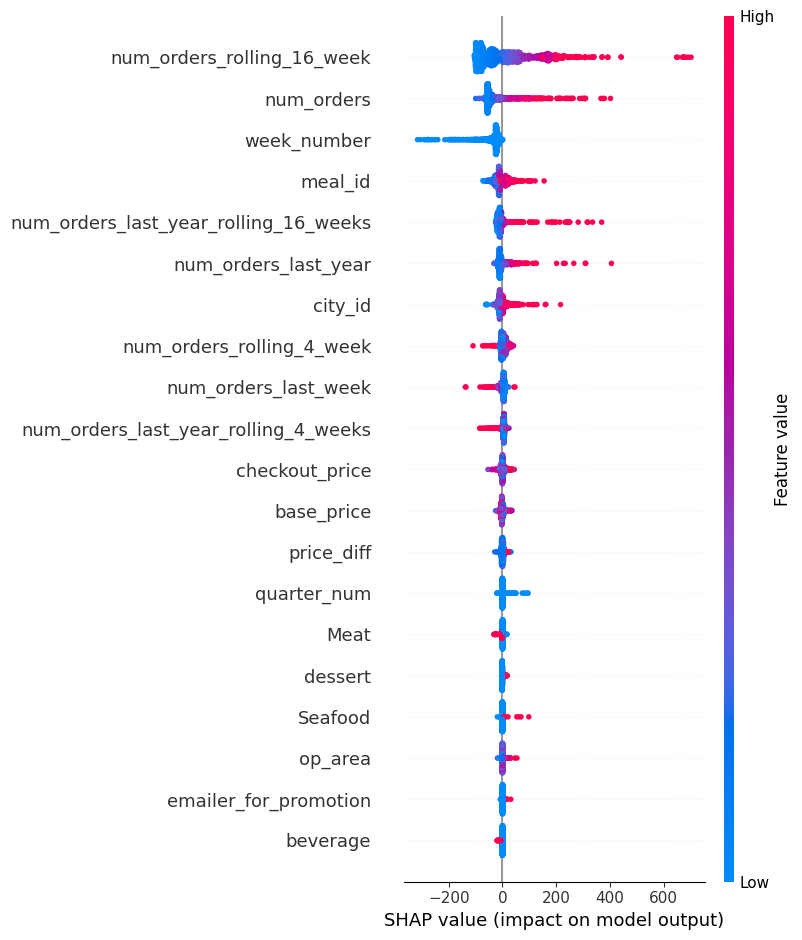

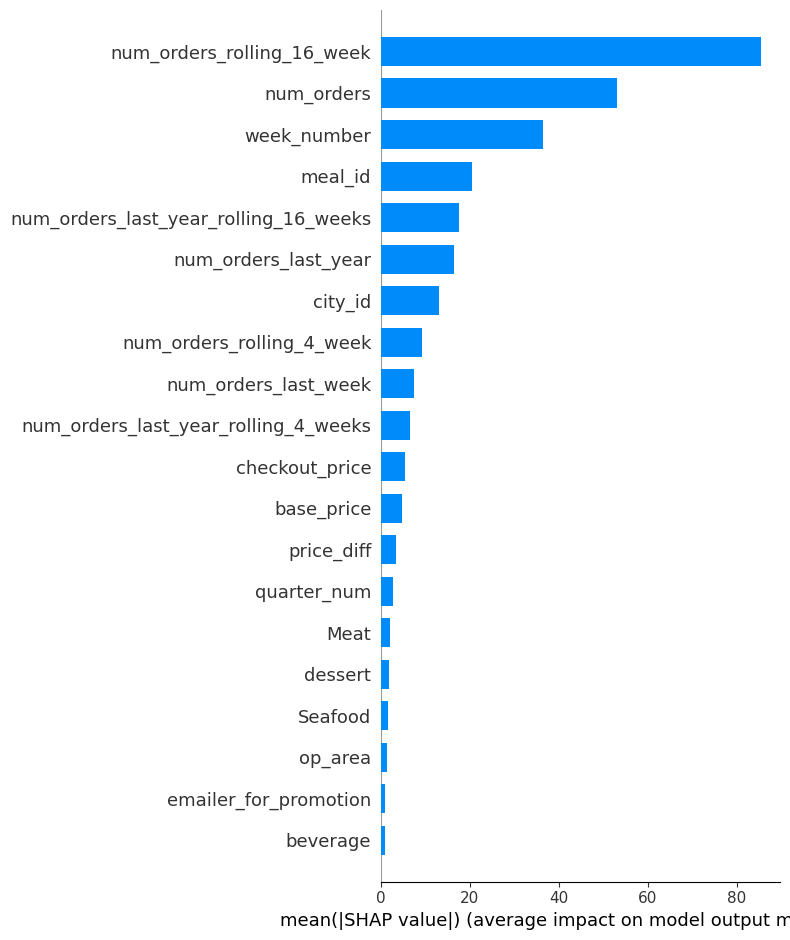

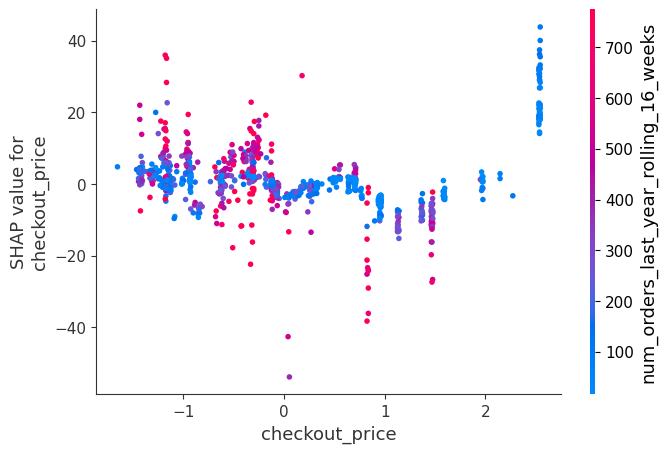

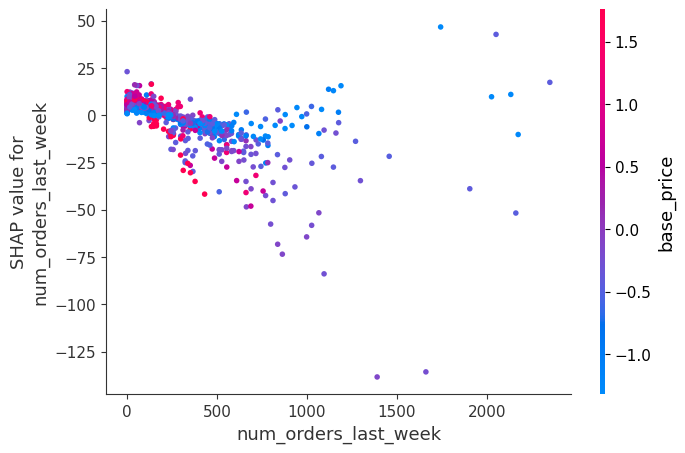

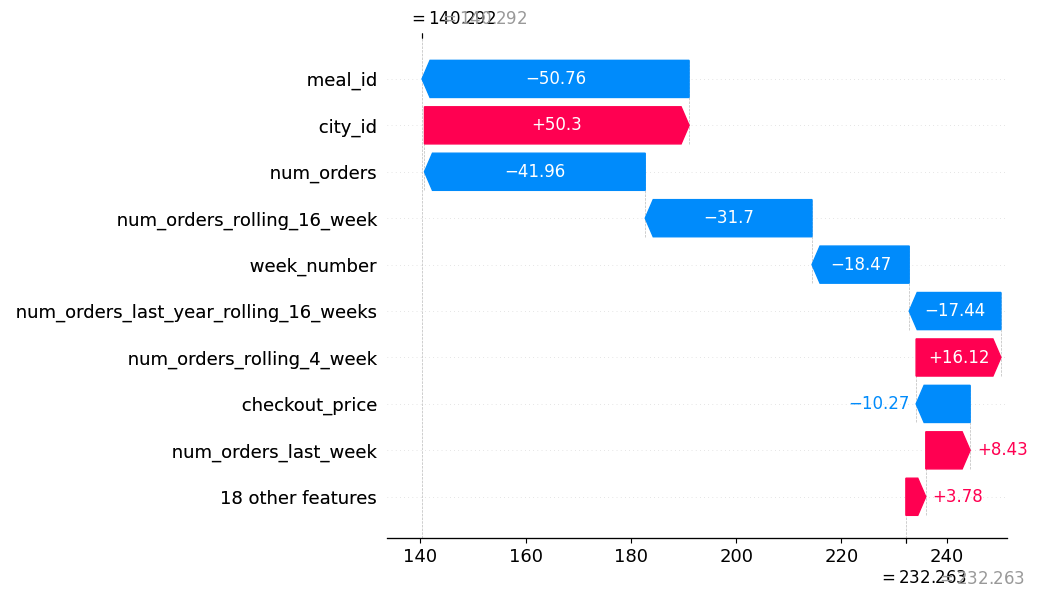

In [1454]:
X = df.drop(columns=['next_week_num_orders', 'week_sin', 'week_cos', 'week_of_year', 'month_num'])
y = df['next_week_num_orders']

X_val_df = df_final_week.drop(columns=['next_week_num_orders', 'week_sin', 'week_cos', 'week_of_year', 'month_num'])


param_grid = {'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 300,
 'subsample': 0.9}


model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **param_grid
)


model.fit(X, y)

# Optional: use only a sample for speed
X_shap = X_val_df.sample(min(1000, len(X_val_df)), random_state=42)

# Build explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X_shap)

# -----------------------------
# 1. Summary beeswarm plot
# -----------------------------
shap.summary_plot(shap_values, X_shap)

# -----------------------------
# 2. Bar plot of feature importance
# -----------------------------
shap.summary_plot(shap_values, X_shap, plot_type="bar")

# -----------------------------
# 3. Dependence plot for one feature
# -----------------------------
shap.dependence_plot("checkout_price", shap_values, X_shap)

# Example for lag feature
shap.dependence_plot("num_orders_last_week", shap_values, X_shap)

# -----------------------------
# 4. Waterfall plot for one prediction
# -----------------------------
row_idx = 0
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[row_idx],
    X_shap.iloc[row_idx]
)

# -----------------------------
# 5. Force plot for one prediction
# -----------------------------
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[row_idx],
    X_shap.iloc[row_idx]
)

In [1054]:
X = df.drop(columns='next_week_num_orders')
y = df['next_week_num_orders']


param_grid = {'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 300,
 'subsample': 0.9}


xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **param_grid
)


xgb.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [1056]:
X = df.drop(columns=['next_week_num_orders'])
y = df['next_week_num_orders']

gbr = GradientBoostingRegressor()

param_grid = {
    "n_estimators": [300],
    "learning_rate": [0.1],
    "max_depth": [3],
    "subsample": [0.8],
    "min_samples_split": [2]
}

gbr.fit(X, y)

GradientBoostingRegressor()

In [250]:
def store_model(model_name, model, artifact_path="artifacts"):
    Path(artifact_path).mkdir(exist_ok=True, parents=True)
    with open(artifact_path + "/" + f"{model_name}.pkl", 'wb') as f:
        dump(model, f) # this would convert the model into byte format and store it in the file.



In [1060]:
!ls artifacts


city_name_encoder.pkl    meal_name_encoder.pkl    xgboost.pkl
gradientBoost.pkl        NeuralNetwork.pkl
meal_info_encoder.pkl    price_scaler_encoder.pkl


## Train a stack of models

In [244]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


In [256]:
df

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,week_of_year,week_sin,week_cos,next_week_num_orders,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks
0,53,-1.052739,-1.135032,0.0,0.0,216.0,4.0,0,0,0,...,1,0.120537,0.992709,257.0,242.0,231.0,203.00,256.0625,0.00,0.0000
1,53,-0.313015,-0.435088,0.0,0.0,351.0,5.1,1,0,0,...,1,0.120537,0.992709,419.0,568.0,188.0,300.50,319.2500,0.00,0.0000
2,53,0.654706,1.200750,0.0,1.0,40.0,3.8,1,0,0,...,1,0.120537,0.992709,107.0,107.0,42.0,31.00,35.7500,0.00,0.0000
3,53,-1.570786,-1.635988,0.0,1.0,1134.0,5.0,0,0,0,...,1,0.120537,0.992709,823.0,621.0,1067.0,908.25,644.7500,0.00,0.0000
4,53,-0.774552,-0.863243,0.0,0.0,217.0,4.4,1,0,0,...,1,0.120537,0.992709,216.0,81.0,189.0,253.50,351.1250,0.00,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319642,144,-0.110307,-0.247797,0.0,0.0,68.0,5.1,1,0,0,...,40,-0.992709,0.120537,42.0,54.0,41.0,44.75,68.1875,47.75,41.8125
319643,144,-0.313015,0.355764,0.0,0.0,54.0,4.1,0,1,0,...,40,-0.992709,0.120537,13.0,80.0,14.0,41.25,34.2500,47.75,35.8125
319644,144,0.951469,2.287161,1.0,1.0,258.0,4.4,0,1,0,...,40,-0.992709,0.120537,26.0,69.0,229.0,128.50,75.5000,57.75,69.4375
319645,144,1.135015,1.080038,0.0,1.0,270.0,3.8,0,0,0,...,40,-0.992709,0.120537,68.0,458.0,190.0,280.50,238.3125,317.25,206.8750


In [411]:
num_future_weeks = 12
param_grid = {'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 300,
 'subsample': 0.9}


for future_week_num in tqdm(list(range(1, num_future_weeks+1))):
    if future_week_num == 1:
        df_i = df.rename(columns={"next_week_num_orders": "target_num_orders"}).copy()
    else:
        df_i["target_num_orders"] = df_i.groupby(['city_id', 'meal_id']).target_num_orders.shift(-1)
        df_i = df_i.dropna().copy()

    print(f"week_num={future_week_num}")
    print(f"len(df)={int(len(df_i))}")
    print(f"max_week={int(df_i.week_number.max())}")

    X = df_i.drop(columns = ['target_num_orders'])
    y = df_i['target_num_orders']

    model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **param_grid
)
    model.fit(X, y)


    store_model(f"boosted_tree_stack_week_{future_week_num}", model)

    
        

  0%|          | 0/12 [00:00<?, ?it/s]

week_num=1
len(df)=319647
max_week=144
week_num=2
len(df)=316109
max_week=143
week_num=3
len(df)=312574
max_week=142
week_num=4
len(df)=309039
max_week=141
week_num=5
len(df)=305505
max_week=140
week_num=6
len(df)=301971
max_week=139
week_num=7
len(df)=298437
max_week=138
week_num=8
len(df)=294903
max_week=137
week_num=9
len(df)=291370
max_week=136
week_num=10
len(df)=287837
max_week=135
week_num=11
len(df)=284307
max_week=134
week_num=12
len(df)=280779
max_week=133


In [ ]:
!ls artifacts

In [ ]:
model